<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/Hawkes_Essay_NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries & Load Dataset

Import all necessary libraries for data analysis and prediction.

In [ ]:
import os
import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import re

import nltk
from nltk import sent_tokenize
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.probability import FreqDist
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score

# Download libraries
for pkg in ["punkt", "stopwords", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

# Load dataset
file_path = "/content/classexampleOpenAI.csv"
df = pd.read_csv(file_path)

print("Loaded dataset from:", file_path)

Loaded dataset from: /content/classexampleOpenAI.csv


# Exploratory Data Analysis

Clean data by standardizing column names and values. Visualize essay distribution across categories and other statistics.

Number of Essays: 89
Column Names: Name, Grade, Course, Date, Teacher, Text, results, grade, summary

Essay Length Stats (Words):
count      89.000000
mean     1162.910112
std       670.164390
min         1.000000
25%       733.000000
50%       967.000000
75%      1446.000000
max      3991.000000
Name: Words, dtype: float64

Essay Length Stats (Characters):
count       89.000000
mean      7050.887640
std       4427.371094
min          4.000000
25%       4454.000000
50%       5567.000000
75%       8503.000000
max      27452.000000
Name: Characters, dtype: float64

Unique Teachers:
['dr. margini' 'ms. morgan' 'mrs. mandel' 'ms. bustamante' 'mr. mccrink'
 'ms. berler' 'dr. morse' 'ms. anderson' 'dr. rhyner' 'macbeth fall essay'
 'mr. lefevere' 'ms. nero' 'dr. chuang' 'dr. bufkin' 'ms. cornick'
 'dr. ermer' 'dr. brown' 'mrs. carson']

Unique Courses:
['digital narrative' 'science fiction and social change'
 'voices from the inside' 'world literature'
 'world civilizations since 1450' 'engl

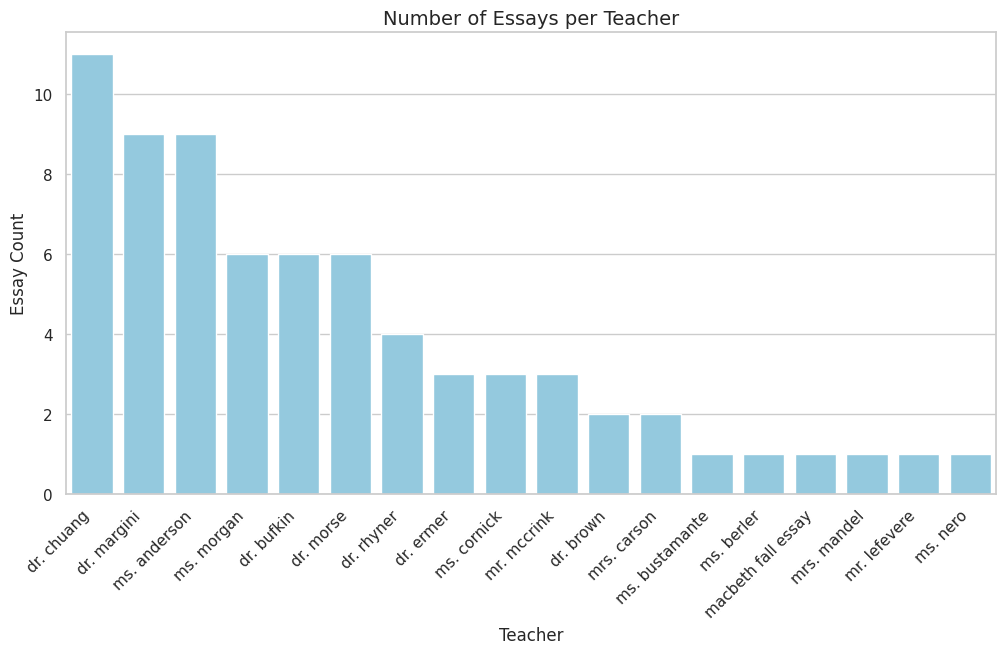

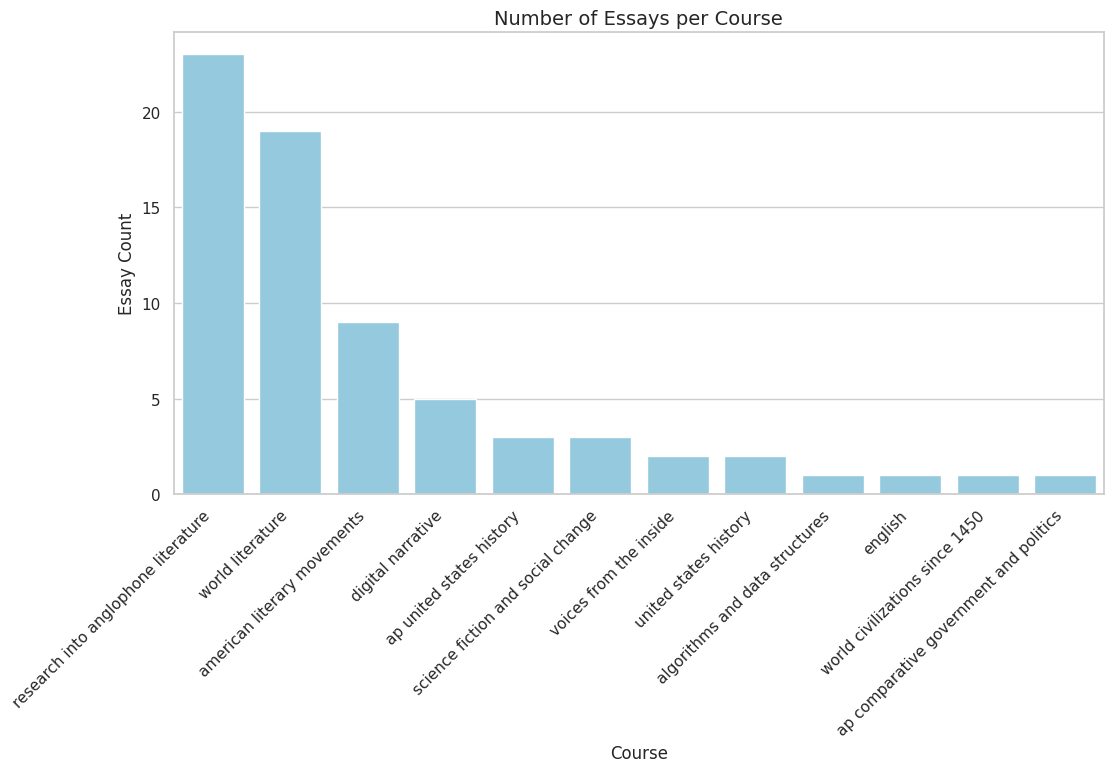

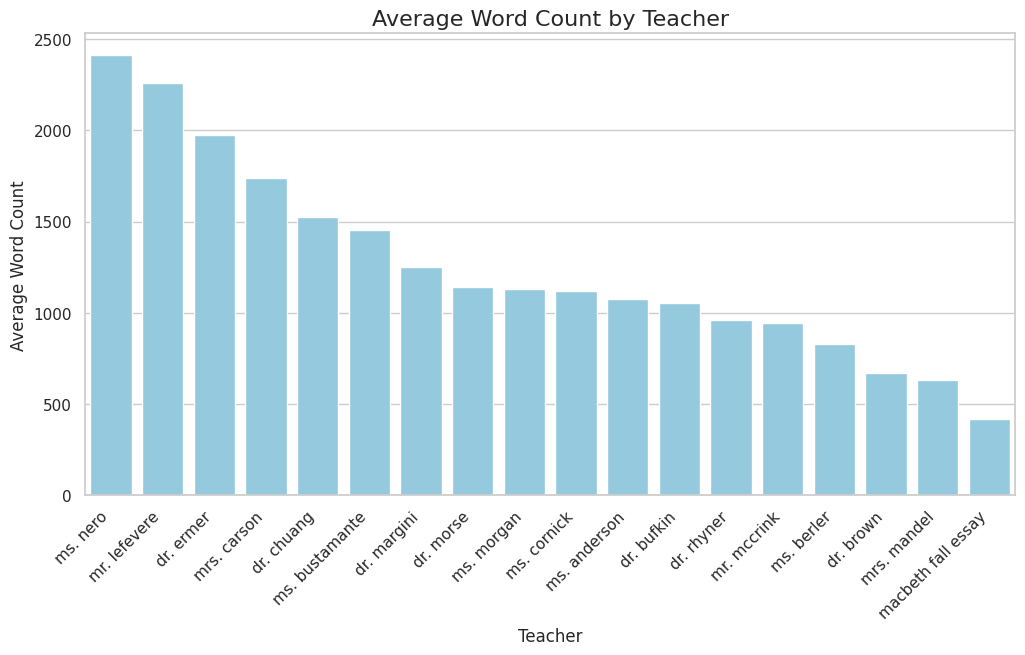

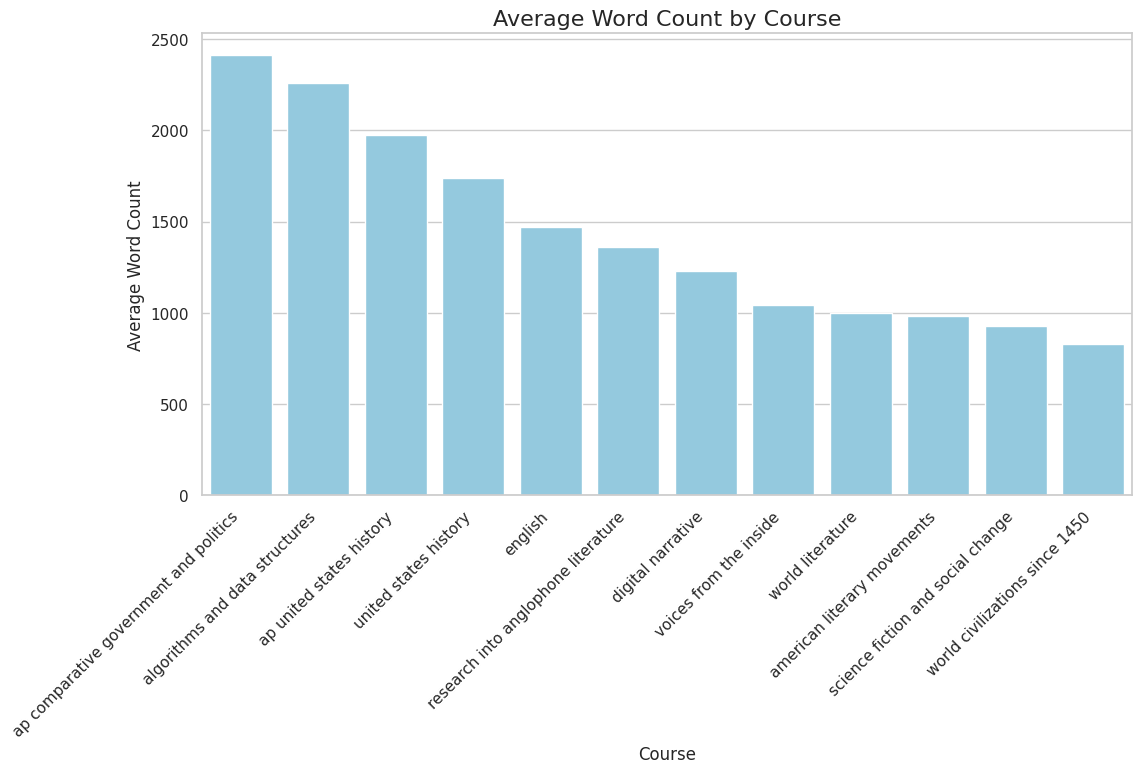

In [ ]:
sns.set(style='whitegrid')

# Determine shape & number of essays/rows
num_essays = df.shape[0]
print("Number of Essays: "+str(num_essays))

# Determine column names
cols = "Column Names: "
for i in range(len(df.columns)-1):
  cols += df.columns[i]+", "

print(cols+df.columns[-1]+"\n")

# Create new columns for word and character count
df['Words'] = df['Text'].str.split().str.len()
df['Characters'] = df['Text'].str.len()

# Essay length statistics
print("Essay Length Stats (Words):")
print(df['Words'].describe())
print("\nEssay Length Stats (Characters):")
print(df['Characters'].describe())
print()
# Clean dataframe
if 37 in df.index:
  df.at[37, 'Course'] = None
df = df.dropna(subset=['Text', 'Teacher', 'Course']).reset_index(drop=True)

def clean_name(name, kind='teacher'):
    if not isinstance(name, str):
        return name

    # Basic cleaning
    name = name.strip()                   # remove leading/trailing spaces
    name = name.replace('.', '. ')        # standardize period spacing
    name = ' '.join(name.split())         # collapse multiple spaces
    name = name.lower()                   # lowercase

    # Standardize common teacher variations
    if kind == 'teacher':
        replacements = {
            'ms anderson': 'ms. anderson',
            'ms.anderson': 'ms. anderson',
            'ms berler': 'ms. berler',
            'ms.berler': 'ms. berler',
            'ms. morse': 'dr. morse',
            'ms.morse': 'dr. morse',       # important fixes
            'ms morse': 'dr. morse',
            'dr morse': 'dr. morse',
            'dr.morse': 'dr. morse',
            'mr mccrink': 'mr. mccrink',
            'mr lefevere': 'mr. lefevere',
            'dr chyung': 'dr. chuang',
            'ms bustamante': 'ms. bustamante',
            'mrs mandel': 'mrs. mandel',
            'dr margini': 'dr. margini',
            'dr bufkin': 'dr. bufkin',
            'ms cornick': 'ms. cornick',
            'dr ermer': 'dr. ermer',
            'dr brown': 'dr. brown',
            'mrs carson': 'mrs. carson',
            'ms nero': 'ms. nero',
            'macbeth fall essay': 'macbeth fall essay',
            'world literature period 2': 'dr. morse',
            'dr. rhyner period 2': 'dr. rhyner',
            'kira morgan': 'ms. morgan'
        }

    # Standardize common course variations
    elif kind == 'course':
        replacements = {
            'american literature movements': 'american literary movements',
            'english 10: american literary movements': 'american literary movements',
            'american literary movements â\x80\x93 6': 'american literary movements',
            'world literature 3rd period': 'world literature',
            'world literature period 3': 'world literature',
            'english 1: world literature': 'world literature',
            'ap united states history period 1': 'ap united states history',
            'english 10 period 3': 'american literary movements',
            'english 10: american literary movements': 'american literary movements',
            'voices from the inside': 'voices from the inside',
            'digital narrative': 'digital narrative',
            'world civilizations since 1450': 'world civilizations since 1450',
            'world literature': 'world literature',
            'english': 'english',
            'research into anglophone literature': 'research into anglophone literature',
            'algorithms and data structures': 'algorithms and data structures',
            'ap comparative government and politics 2022-23': 'ap comparative government and politics',
            'ap united states history': 'ap united states history',
            'united states history': 'united states history',
            'english 10': 'american literary movements',
            'world literature period 2': 'world literature',
            'dr. morse': 'world literature'
        }

    else:
        replacements = {}

    # Apply replacements if match
    name = replacements.get(name, name)
    return name

# Apply normalization
df['Teacher'] = df['Teacher'].apply(lambda x: clean_name(x, kind='teacher'))
df['Course'] = df['Course'].apply(lambda x: clean_name(x, kind='course'))

# Unique teachers
print("Unique Teachers:")
print(df['Teacher'].unique())

# Unique courses
print("\nUnique Courses:")
print(df['Course'].unique())

# Num essays per teacher
teacher_counts = df['Teacher'].value_counts().reset_index()
teacher_counts.columns = ['Teacher', 'Count']

plt.figure(figsize=(12,6))
sns.barplot(data=teacher_counts, x='Teacher', y='Count', color='skyblue')

plt.title("Number of Essays per Teacher", fontsize=14)
plt.xlabel("Teacher", fontsize=12)
plt.ylabel("Essay Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# Num essays per course
course_counts = df['Course'].value_counts().reset_index()
course_counts.columns = ['Course', 'Count']

plt.figure(figsize=(12,6))
sns.barplot(data=course_counts, x='Course', y='Count', color='skyblue')

plt.title("Number of Essays per Course", fontsize=14)
plt.xlabel("Course", fontsize=12)
plt.ylabel("Essay Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# Avg essay word count per teacher
words_by_teacher = df.groupby('Teacher')['Words'].mean().reset_index()
words_by_teacher = words_by_teacher.sort_values('Words', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=words_by_teacher, x='Teacher', y='Words', color='skyblue')

plt.title("Average Word Count by Teacher", fontsize=16)
plt.xlabel("Teacher", fontsize=12)
plt.ylabel("Average Word Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# Avg essay word count per course
words_by_course = df.groupby('Course')['Words'].mean().reset_index()
words_by_course = words_by_course.sort_values('Words', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=words_by_course, x='Course', y='Words', color='skyblue')

plt.title("Average Word Count by Course", fontsize=16)
plt.xlabel("Course", fontsize=12)
plt.ylabel("Average Word Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# Text Preprocessing

Preprocess the text by removing stop words and lemmatizing words. Tokenize the texts and create a new column. Visualize the frequency of a word in all the essays through a graph. Generate a WordCloud to easily see this distribution.

In [ ]:
# Stopwords + lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords + very short tokens
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

df['tokens'] = df['Text'].apply(preprocess_text)

In [ ]:
# Find the frequency of a word in all the essays

words = [word for essay in df['tokens'] for word in essay]
fdist = FreqDist(words)

fdist.most_common(20)

[('life', 246),
 ('people', 241),
 ('would', 221),
 ('human', 221),
 ('power', 211),
 ('macbeth', 204),
 ('victor', 201),
 ('frankenstein', 191),
 ('monster', 185),
 ('society', 181),
 ('one', 178),
 ('state', 172),
 ('also', 165),
 ('american', 160),
 ('story', 158),
 ('world', 157),
 ('nation', 155),
 ('shelley', 150),
 ('like', 136),
 ('character', 134)]

<Axes: xlabel='Samples', ylabel='Counts'>

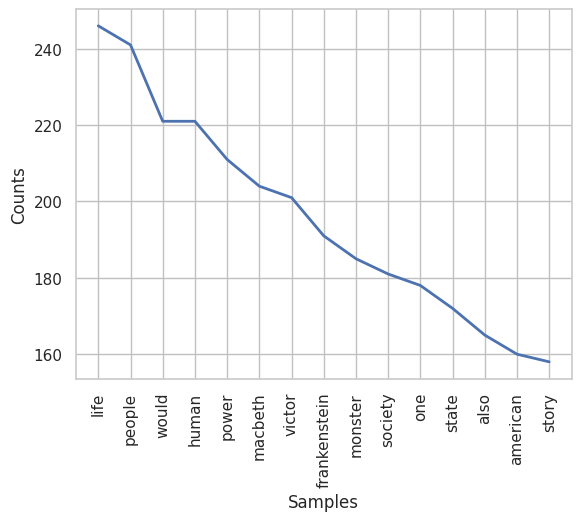

In [ ]:
# Visualize most common words
fdist.plot(15)

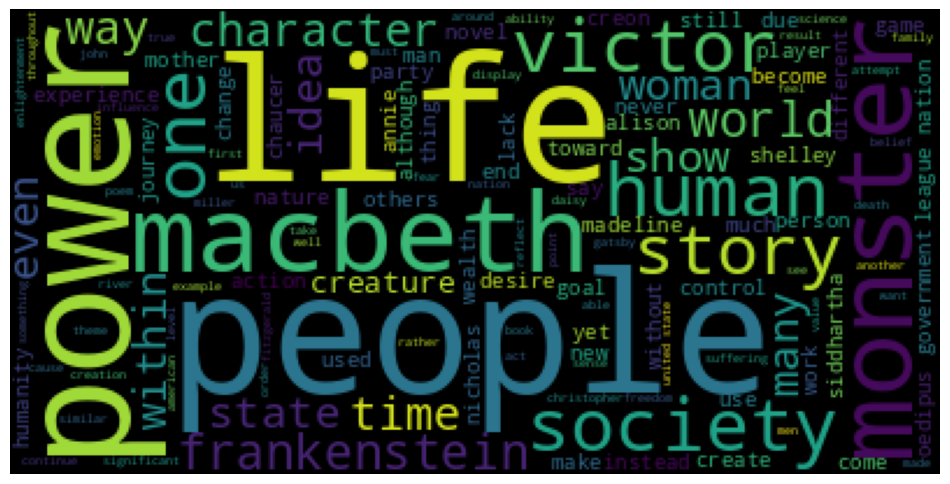

In [ ]:
# Convert token column into singular text string
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))

#Generating the wordcloud :
wordcloud = WordCloud().generate(' '.join(df['processed_text']))

#Plot the wordcloud :
plt.figure(figsize = (12, 12))
plt.imshow(wordcloud)

#To remove the axis value :
plt.axis("off")
plt.show()

# Text Vectorization

Vectorize the preprocessed text three ways: unigrams, unigrams+bigrams, unigrams+bigrams+trigrams. In this step, I visualized the three processes using only a singular text, just to get a sense of the types of vectorization. In the main dataset, I vectorized all the texts using unigrams+bigrams.

In [ ]:
import random
from sklearn.feature_extraction.text import TfidfVectorizer

# Pick a text
sample_text = [df.loc[5, 'processed_text']]
print("Text:\n", sample_text[0])

# Unigram
tfidf_uni = TfidfVectorizer(ngram_range=(1,1))
X_uni = tfidf_uni.fit_transform(sample_text)
print("\nUnigram feature names:", tfidf_uni.get_feature_names_out())
print("Unigram vector shape:", X_uni.shape)
print("Unigram vector:\n", X_uni.toarray())

# Unigram + Bigram
tfidf_bi = TfidfVectorizer(ngram_range=(1,2))
X_bi = tfidf_bi.fit_transform(sample_text)
print("\nUnigram + Bigram feature names:", tfidf_bi.get_feature_names_out())
print("Bigram vector shape:", X_bi.shape)
print("Bigram vector:\n", X_bi.toarray())

# Unigram + Bigram + Trigram
tfidf_tri = TfidfVectorizer(ngram_range=(1,3))
X_tri = tfidf_tri.fit_transform(sample_text)
print("\nUnigram + Bigram + Trigram feature names:", tfidf_tri.get_feature_names_out())
print("Trigram vector shape:", X_tri.shape)
print("Trigram vector:\n", X_tri.toarray())

Text:
 spending significant amount life isolated town middle nowhere hungary justice system wasnt forefront anyone elses life small town like criminal activity largely overlooked wasnt much criminal activity acknowledge police possibly good reason undergeared using equipment seemed less effective compared ive experienced america however america justice system stick unfairness seen michelle alexander new jim crow american justice system although claiming colorblind far fair justice system claim subtly oppresses racial minority goal ensuring people treated equally face justice system however system requires reparation community oppressed current one new jim crow highlight perfect example happens justice skewed hand authority plight minority community come zooming specific part america florida prison echo idea new jim crow also longstanding history abuse continues today florida department correction third largest state prison system united state housing around inmate fdc florida overall i

# Teacher Prediction

## Train / Validation / Test Split

Split the data and vectorize the data using unigrams+bigrams.

In [ ]:
# Train/Val/Test split
def split_and_vectorize(text_series, y, ngram_range=(1,2), min_df=2, random_state=42):
    counts = y.value_counts()
    rare_classes = counts[counts < 2].index.tolist()

    if len(rare_classes) > 0:
        print("Dropping rare classes (only 1 sample) so stratified splitting works:")
        print(rare_classes)

        mask = ~y.isin(rare_classes)
        text_series = text_series[mask]
        y = y[mask]

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        text_series,
        y,
        test_size=0.20,
        stratify=y,
        random_state=random_state
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval,
        y_trainval,
        test_size=0.25,   # 0.25 of 0.80 = 0.20 of total
        stratify=y_trainval,
        random_state=random_state
    )

    print("Train size:", len(X_train))
    print("Validation size:", len(X_val))
    print("Test size:", len(X_test))

    # Vectorization
    tfidf = TfidfVectorizer(ngram_range=ngram_range, min_df=min_df)
    X_train_vec = tfidf.fit_transform(X_train)
    X_val_vec = tfidf.transform(X_val)
    X_test_vec = tfidf.transform(X_test)

    return tfidf, (X_train, X_val, X_test), (y_train, y_val, y_test), (X_train_vec, X_val_vec, X_test_vec)

# Labels (Teacher task)
y_teacher = df['Teacher']

# Split + vectorize
tfidf_teacher, (X_train_t, X_val_t, X_test_t), (y_train_t, y_val_t, y_test_t), (X_train_vec_t, X_val_vec_t, X_test_vec_t) = split_and_vectorize(
    df['processed_text'],
    y_teacher,
    ngram_range=(1,2),
    min_df=2,
    random_state=42
)


Dropping rare classes (only 1 sample) so stratified splitting works:
['ms. bustamante', 'ms. berler', 'macbeth fall essay', 'mrs. mandel', 'mr. lefevere', 'ms. nero']
Train size: 38
Validation size: 13
Test size: 13


## Supervised Classification Models

Create the models (logisitic regression, decision tree) and predict the teacher name. Evaluate the model performance with metrics.

Validation Results (sorted by Weighted F1):


,Model,Params,Val_F1
2,Logistic Regression,C=3,0.369963
0,Logistic Regression,C=0.5,0.305861
1,Logistic Regression,C=1,0.293040
5,Decision Tree,"depth=15, leaf=1",0.276923
4,Decision Tree,"depth=8, leaf=3",0.153846
6,Decision Tree,"depth=15, leaf=3",0.153846
3,Decision Tree,"depth=8, leaf=1",0.138462



Best Model on Validation:
Logistic Regression - C=3

Teacher Prediction - Test Metrics:
Accuracy: 0.6154
F1 (weighted): 0.541
F1 (macro): 0.4767

Classification Report:
              precision    recall  f1-score   support

  dr. bufkin       0.00      0.00      0.00         1
  dr. chuang       1.00      0.50      0.67         2
   dr. ermer       1.00      1.00      1.00         1
 dr. margini       0.67      1.00      0.80         2
   dr. morse       0.00      0.00      0.00         1
  dr. rhyner       0.00      0.00      0.00         1
 mr. mccrink       0.00      0.00      0.00         1
ms. anderson       0.67      1.00      0.80         2
 ms. cornick       1.00      1.00      1.00         1
  ms. morgan       0.33      1.00      0.50         1

    accuracy                           0.62        13
   macro avg       0.47      0.55      0.48        13
weighted avg       0.54      0.62      0.54        13

Majority-class baseline accuracy: 0.1538
Random guessing baseline accur

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


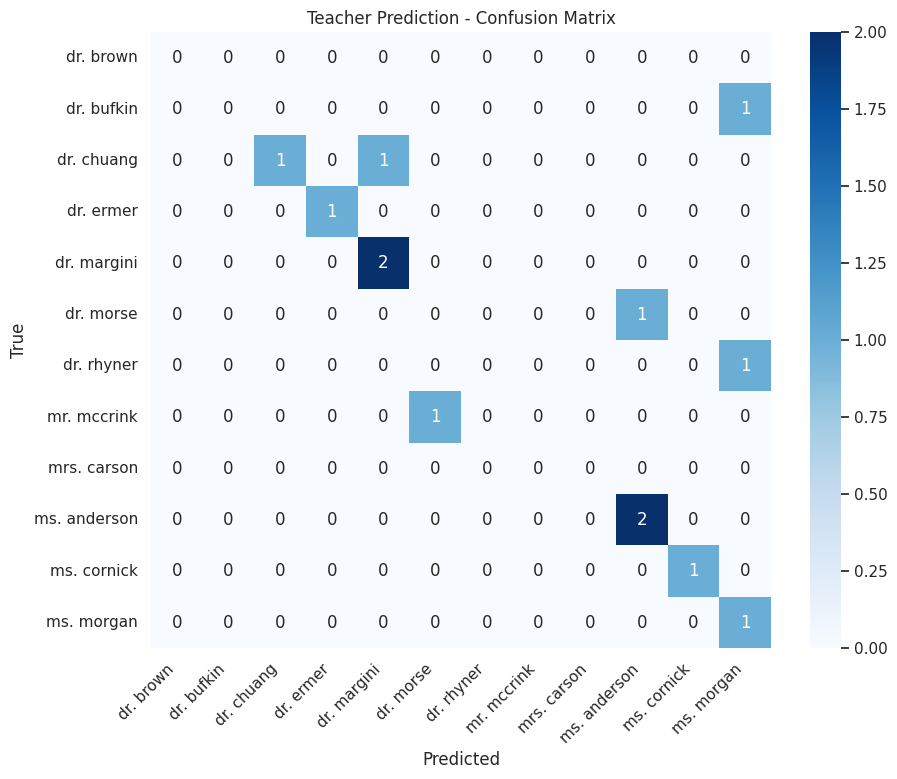


Top Weighted Features Per Teacher (LogReg):

dr. brown: ['thoreau', 'matrix', 'government', 'slave', 'neo', 'writes', 'liberty', 'freedom', 'lived', 'people', 'ship', 'allowed']

dr. bufkin: ['matrix', 'technology', 'rich', 'project', 'wealth', 'emerson', 'human', 'machine', 'wealthy', 'myrtle', 'society', 'narrator']

dr. chuang: ['frankenstein', 'monster', 'poem', 'beauty', 'human', 'creature', 'field', 'shelley', 'art', 'old man', 'immortality', 'miller']

dr. ermer: ['progressive', 'nation', 'island', 'united', 'rebellion', 'united state', 'political', 'democracy', 'democrat', 'politics', 'right', 'state']

dr. margini: ['player', 'game', 'character', 'miller', 'victor', 'poem', 'monster', 'wife', 'narrative', 'sea', 'love', 'absolon']

dr. morse: ['siddhartha', 'macbeth', 'mother', 'annie', 'sentence', 'father', 'vasudeva', 'hero', 'voice', 'hesse', 'change', 'learns']

dr. rhyner: ['hero', 'neo', 'money', 'fitzgerald', 'myrtle', 'daisy', 'definition', 'journey', 'agent', 'smith'

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from scipy.sparse import vstack
import numpy as np

# Store results
results = []

# 1. Logistic Regression
C_values = [0.5, 1, 3]

for C in C_values:
    lr = LogisticRegression(
        C=C,
        max_iter=3000,
        class_weight='balanced'
    )
    lr.fit(X_train_vec_t, y_train_t)

    val_pred = lr.predict(X_val_vec_t)
    val_f1 = f1_score(y_val_t, val_pred, average='weighted')

    results.append({
        "Model": "Logistic Regression",
        "Params": f"C={C}",
        "Val_F1": val_f1
    })

# 2. Decision Tree
depths = [8, 15]
leaf_sizes = [1, 3]

for d in depths:
    for l in leaf_sizes:
        dt = DecisionTreeClassifier(
            max_depth=d,
            min_samples_leaf=l,
            class_weight='balanced',
            random_state=42
        )
        dt.fit(X_train_vec_t, y_train_t)

        val_pred = dt.predict(X_val_vec_t)
        val_f1 = f1_score(y_val_t, val_pred, average='weighted')

        results.append({
            "Model": "Decision Tree",
            "Params": f"depth={d}, leaf={l}",
            "Val_F1": val_f1
        })

# Results Summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Val_F1", ascending=False)

print("Validation Results (sorted by Weighted F1):")
display(results_df.head(10))

best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_params = best_row["Params"]

print("\nBest Model on Validation:")
print(best_model_name, "-", best_params)

# Train best model on Train+Val, then evaluate on Test
X_trainval_vec = vstack([X_train_vec_t, X_val_vec_t])
y_trainval = pd.concat([y_train_t, y_val_t])

def build_model(model_name, params_str):
    if model_name == "Logistic Regression":
        C = float(params_str.split("=")[1])
        return LogisticRegression(C=C, max_iter=3000, class_weight='balanced')

    if model_name == "Decision Tree":
        # params_str like "depth=15, leaf=3"
        parts = {kv.split("=")[0].strip(): kv.split("=")[1].strip() for kv in params_str.split(",")}
        return DecisionTreeClassifier(
            max_depth=int(parts["depth"]),
            min_samples_leaf=int(parts["leaf"]),
            class_weight='balanced',
            random_state=42
        )

    raise ValueError("Unknown model")

best_model = build_model(best_model_name, best_params)
best_model.fit(X_trainval_vec, y_trainval)

test_pred = best_model.predict(X_test_vec_t)
test_acc = accuracy_score(y_test_t, test_pred)
test_f1w = f1_score(y_test_t, test_pred, average='weighted')
test_f1m = f1_score(y_test_t, test_pred, average='macro')

print("\nTeacher Prediction - Test Metrics:")
print("Accuracy:", round(test_acc, 4))
print("F1 (weighted):", round(test_f1w, 4))
print("F1 (macro):", round(test_f1m, 4))
print("\nClassification Report:")
print(classification_report(y_test_t, test_pred))

# Majority class + random guessing
majority_class = y_trainval.value_counts().idxmax()
baseline_majority = np.mean(y_test_t == majority_class)
baseline_random = 1 / y_trainval.nunique()

print("Majority-class baseline accuracy:", round(baseline_majority, 4))
print("Random guessing baseline accuracy:", round(baseline_random, 4))

# Confusion Matrix (Teacher)
cm = confusion_matrix(y_test_t, test_pred, labels=sorted(y_trainval.unique()))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_trainval.unique()),
            yticklabels=sorted(y_trainval.unique()))
plt.title("Teacher Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# Interpretability (Teacher) - Top words per class (Logistic Regression only)
if best_model_name == "Logistic Regression":
    feature_names = tfidf_teacher.get_feature_names_out()
    classes = best_model.classes_
    coefs = best_model.coef_

    print("\nTop Weighted Features Per Teacher (LogReg):")
    for i, cls in enumerate(classes):
        top_idx = np.argsort(coefs[i])[-12:][::-1]
        top_terms = [feature_names[j] for j in top_idx]
        print(f"\n{cls}: {top_terms}")

# Error Analysis (Teacher) - show a few misclassified examples
mis_idx = np.where(test_pred != y_test_t.values)[0]
print("\nNumber of misclassified test essays:", len(mis_idx))

for j in mis_idx[:3]:
    true_label = y_test_t.iloc[j]
    pred_label = test_pred[j]
    raw_text = X_test_t.iloc[j]
    print("True:", true_label, "| Pred:", pred_label)
    print("Excerpt:", raw_text[:300], "...")


# Subject (Course) Prediction

Repeat the same teacher pipeline with the course prediction this time.

Dropping rare classes (only 1 sample) so stratified splitting works:
['algorithms and data structures', 'english', 'world civilizations since 1450', 'ap comparative government and politics']
Train size: 39
Validation size: 13
Test size: 14
Validation Results (Course) - sorted by Weighted F1:


,Model,Params,Val_F1
2,Logistic Regression,C=3,0.892308
0,Logistic Regression,C=0.5,0.827839
1,Logistic Regression,C=1,0.827839
3,Decision Tree,"depth=8, leaf=1",0.526340
5,Decision Tree,"depth=15, leaf=1",0.526340
4,Decision Tree,"depth=8, leaf=3",0.252137
6,Decision Tree,"depth=15, leaf=3",0.252137



Best Course Model on Validation:
Logistic Regression - C=3

Course Prediction - Test Metrics:
Accuracy: 0.9286
F1 (weighted): 0.9286
F1 (macro): 0.7143

Classification Report:
                                     precision    recall  f1-score   support

        american literary movements       1.00      1.00      1.00         2
           ap united states history       0.00      0.00      0.00         1
                  digital narrative       1.00      1.00      1.00         1
research into anglophone literature       1.00      1.00      1.00         5
  science fiction and social change       1.00      1.00      1.00         1
              united states history       0.00      0.00      0.00         0
                   world literature       1.00      1.00      1.00         4

                           accuracy                           0.93        14
                          macro avg       0.71      0.71      0.71        14
                       weighted avg       0.93     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

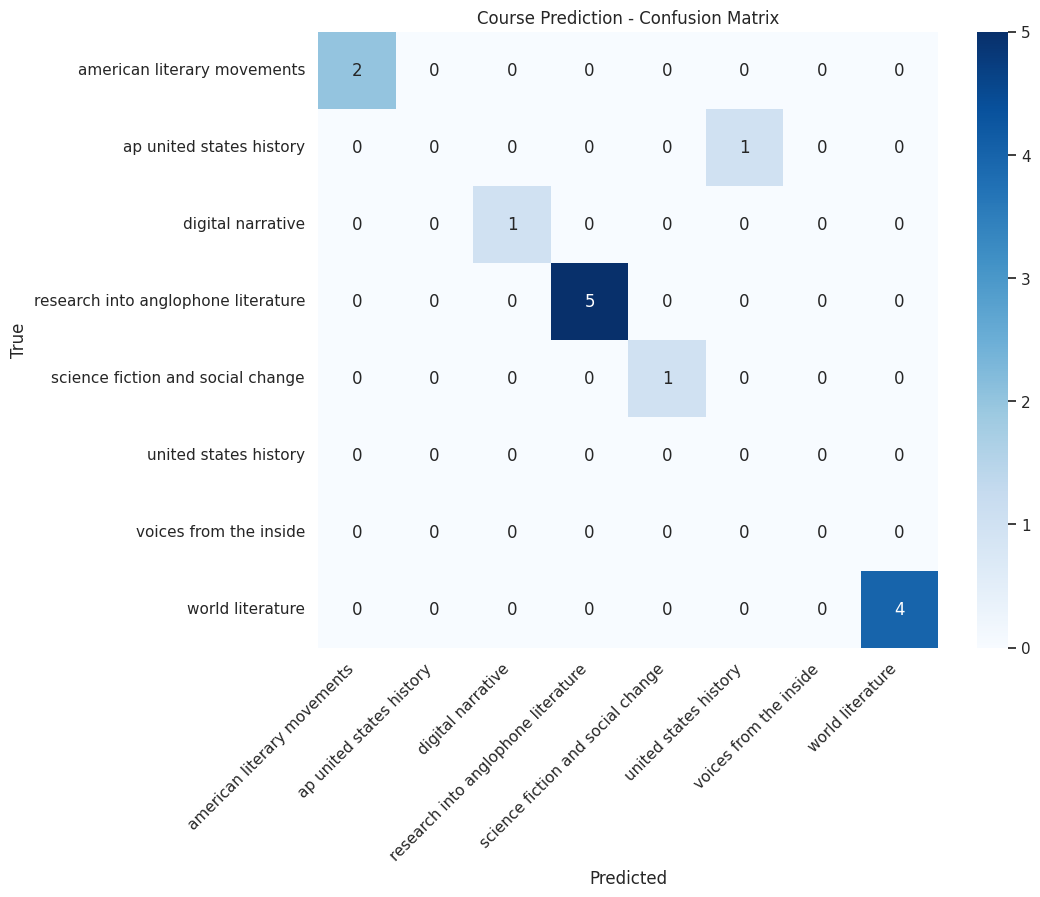


Top Weighted Features Per Course (LogReg):

american literary movements: ['myrtle', 'matrix', 'money', 'daisy', 'wealth', 'enlightenment', 'gatsby', 'technology', 'god', 'thoreau', 'party', 'emerson']

ap united states history: ['nation', 'united', 'united state', 'policy', 'imperialism', 'international', 'wilson', 'failure', 'foreign', 'state', 'peace', 'structure']

digital narrative: ['player', 'game', 'character', 'narrative', 'room', 'design', 'gameplay', 'citizen sleeper', 'part', 'dialogue', 'theme', 'central']

research into anglophone literature: ['victor', 'chaucer', 'monster', 'shelley', 'poem', 'frankenstein', 'woman', 'miller', 'tale', 'nicholas', 'wife', 'alison']

science fiction and social change: ['human', 'one state', 'citizen', 'government', 'freedom', 'answer', 'happiness', 'free', 'animal', 'zamyatin', 'mean human', 'emotion']

united states history: ['war', 'american', 'right', 'civil', 'civil right', 'african', 'party', 'black', 'would', 'military', 'economic', 

In [ ]:
from scipy.sparse import vstack

# Labels (Course task)
y_course = df['Course']

# Split + vectorize (same settings to keep comparison fair)
tfidf_course, (X_train_c, X_val_c, X_test_c), (y_train_c, y_val_c, y_test_c), (X_train_vec_c, X_val_vec_c, X_test_vec_c) = split_and_vectorize(
    df['processed_text'],
    y_course,
    ngram_range=(1,2),
    min_df=2,
    random_state=42
)

# Store results
results_course = []

# 1. Logistic Regression
C_values = [0.5, 1, 3]

for C in C_values:
    lr = LogisticRegression(
        C=C,
        max_iter=3000,
        class_weight='balanced'
    )
    lr.fit(X_train_vec_c, y_train_c)

    val_pred = lr.predict(X_val_vec_c)
    val_f1 = f1_score(y_val_c, val_pred, average='weighted')

    results_course.append({
        "Model": "Logistic Regression",
        "Params": f"C={C}",
        "Val_F1": val_f1
    })

# 2. Decision Tree
depths = [8, 15]
leaf_sizes = [1, 3]

for d in depths:
    for l in leaf_sizes:
        dt = DecisionTreeClassifier(
            max_depth=d,
            min_samples_leaf=l,
            class_weight='balanced',
            random_state=42
        )
        dt.fit(X_train_vec_c, y_train_c)

        val_pred = dt.predict(X_val_vec_c)
        val_f1 = f1_score(y_val_c, val_pred, average='weighted')

        results_course.append({
            "Model": "Decision Tree",
            "Params": f"depth={d}, leaf={l}",
            "Val_F1": val_f1
        })

# Results Summary
results_course_df = pd.DataFrame(results_course).sort_values(by="Val_F1", ascending=False)

print("Validation Results (Course) - sorted by Weighted F1:")
display(results_course_df.head(10))

best_row_c = results_course_df.iloc[0]
best_model_name_c = best_row_c["Model"]
best_params_c = best_row_c["Params"]

print("\nBest Course Model on Validation:")
print(best_model_name_c, "-", best_params_c)

# Train best model on Train+Val, then evaluate on Test
X_trainval_vec_c = vstack([X_train_vec_c, X_val_vec_c])
y_trainval_c = pd.concat([y_train_c, y_val_c])

best_model_c = build_model(best_model_name_c, best_params_c)
best_model_c.fit(X_trainval_vec_c, y_trainval_c)

test_pred_c = best_model_c.predict(X_test_vec_c)
test_acc_c = accuracy_score(y_test_c, test_pred_c)
test_f1w_c = f1_score(y_test_c, test_pred_c, average='weighted')
test_f1m_c = f1_score(y_test_c, test_pred_c, average='macro')

print("\nCourse Prediction - Test Metrics:")
print("Accuracy:", round(test_acc_c, 4))
print("F1 (weighted):", round(test_f1w_c, 4))
print("F1 (macro):", round(test_f1m_c, 4))
print("\nClassification Report:")
print(classification_report(y_test_c, test_pred_c))

# Baselines
majority_class_c = y_trainval_c.value_counts().idxmax()
baseline_majority_c = np.mean(y_test_c == majority_class_c)
baseline_random_c = 1 / y_trainval_c.nunique()

print("Majority-class baseline accuracy:", round(baseline_majority_c, 4))
print("Random guessing baseline accuracy:", round(baseline_random_c, 4))

# Confusion Matrix (Course)
cm_c = confusion_matrix(y_test_c, test_pred_c, labels=sorted(y_trainval_c.unique()))
plt.figure(figsize=(10,8))
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y_trainval_c.unique()),
            yticklabels=sorted(y_trainval_c.unique()))
plt.title("Course Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# Interpretability (Course) - Top words per class (Logistic Regression only)
if best_model_name_c == "Logistic Regression":
    feature_names_c = tfidf_course.get_feature_names_out()
    classes_c = best_model_c.classes_
    coefs_c = best_model_c.coef_

    print("\nTop Weighted Features Per Course (LogReg):")
    for i, cls in enumerate(classes_c):
        top_idx = np.argsort(coefs_c[i])[-12:][::-1]
        top_terms = [feature_names_c[j] for j in top_idx]
        print(f"\n{cls}: {top_terms}")

# Error Analysis (Course)
mis_idx_c = np.where(test_pred_c != y_test_c.values)[0]
print("\nNumber of misclassified test essays (Course):", len(mis_idx_c))

for j in mis_idx_c[:3]:
    true_label = y_test_c.iloc[j]
    pred_label = test_pred_c[j]
    raw_text = X_test_c.iloc[j]
    print("True:", true_label, "| Pred:", pred_label)
    print("Excerpt:", raw_text[:300], "...")


# Teacher vs Course Comparison

In many datasets, course prediction is easier because topics have distinctive vocabulary.

Teacher prediction can be harder if multiple teachers assign similar prompts and students write similarly across classes.

For courses, each essay will have specific topics related to them, and therefore will be easier to predict.


# Limitations & Proposed Improvements

Possible limitations
- Small dataset size (not many essays per class)
- Class imbalance (some teachers/courses have very few examples)
- Overlapping vocabulary between labels (similar prompts or topics)
- Essays may cover multiple topics at once
- Inconsistent essay length and writing quality

Improvements
1. Collect more essays per teacher/course to reduce variance and imbalance.
2. Try larger n-grams (1,3) and compare again (especially for course-specific phrases).
3. Use lemmatization + POS tagging or keep punctuation features to capture teacher style.
4. Try word embeddings (Word2Vec/GloVe) or transformer embeddings (BERT) for richer semantics.
5. Use ensemble methods (stacking / voting) or calibrated models for better generalization.
